Detected inversion years: [1997 1998 2013 2019 2021]


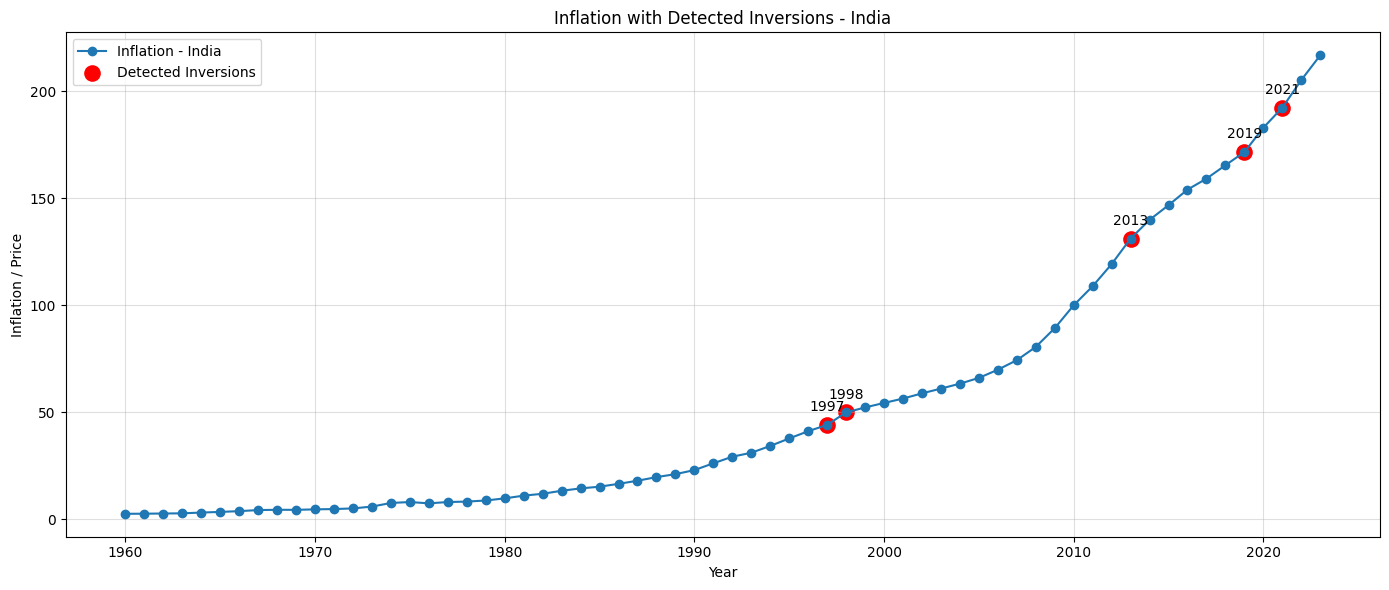

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('./data/infaltion.csv')
df['Year'] = df['Year'].astype(int)

# Choose country
country = "India"  # Change to any country of interest
country_data = df[df['Entity'] == country].sort_values('Year')

# Extract series
years = country_data['Year'].values
values = country_data['price'].values

# --- 1. Compute difference matrix (2nd difference) ---
first_diff = np.diff(values)
second_diff = np.diff(first_diff)

# --- 2. Find inversion points ---
# Threshold: here we'll use std-based detection
threshold = np.std(second_diff) * 2   # 2× standard deviation
inversion_indices = np.where(np.abs(second_diff) > threshold)[0] + 1  # +1 to align to original index

inversion_years = years[inversion_indices]
inversion_values = values[inversion_indices]

print("Detected inversion years:", inversion_years)

# --- 3. Plot ---
plt.figure(figsize=(14,6))
plt.plot(years, values, marker='o', label=f'Inflation - {country}')
plt.scatter(inversion_years, inversion_values, color='red', s=120, label='Detected Inversions')
for y, v in zip(inversion_years, inversion_values):
    plt.annotate(f"{y}", (y, v), textcoords="offset points", xytext=(0,10), ha='center')
plt.title(f"Inflation with Detected Inversions - {country}")
plt.xlabel("Year")
plt.ylabel("Inflation / Price")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()